### Importacion y configuracion

In [1]:
# Imports base para los ejemplos
from pathlib import Path
import sys
import numpy as np

# Asegura que src/ este en el path del notebook
root = Path.cwd().resolve()
src_path = root / "src"
if not src_path.exists():
    src_path = root.parent / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

# Importa modelos, parametros y utilidades de visualizacion
from model2D_v3 import Params2D, KMC2D, KMC2DVisualizer
from params_v4 import KMCParams_v4
from lattice_v4 import LatticeSOS_v4
from bkl_v4 import KMC_BKL_v4
from plotter import Plotter

# Carpeta de salida para GIFs
out_dir = root / "results" / "modelos_gifs"
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
root

WindowsPath('C:/Users/sebas/MalariaProject/notebooks')

### Modelo 2D isotropico sin solvente

In [4]:
# Modelo 2D isotropico sin solvente
p2d_iso = Params2D(
    Jad_x=0.04, Jad_y=0.04,
    Jinc_x=0.01, Jinc_y=0.01,
    Jdes_x=0.05, Jdes_y=0.05,
    Jmove_x=0.03, Jmove_y=0.03,
    solvent_ads_factor=0.1,
    solvent_des_factor=0.1,
    solvent_diff_factor=0.1,
    solvent_inc_factor=0.1,
 )
 # Ejecuta el motor sin anisotropia y sin solvente
kmc2d_iso = KMC2D(p2d_iso, seed=1, use_anisotropy=False, use_solvent=False)

# Corre con snapshots para visualizacion
times_2d_iso, cover_2d_iso, snapshots_2d_iso = kmc2d_iso.run_until(
    tmax=4.0, snapshot_every=1.0, store_snapshots=True
 )
grid_2d_iso = snapshots_2d_iso[-1][1] if snapshots_2d_iso else kmc2d_iso.grid.copy()
final_t = float(times_2d_iso[-1]) if len(times_2d_iso) else 0.0
final_cover = float(cover_2d_iso[-1]) if len(cover_2d_iso) else 0.0
print("2D isotropico sin solvente:", final_t, final_cover)

0.0
0.460211265957598
0.8100915042739736
0.9932070476518712
1.2310180754086744
1.3560509372071627
1.481531537785739
1.612171099335505
1.7738890342172544
1.930061710462336
1.9967535525178777
2.123558421294161
2.1740277758891957
2.254468135545758
2.318205332307518
2.3844145798839853
2.4497353952560013
2.518361203757235
2.5835041614124887
2.6426812233700536
2.716179522139646
2.7738092790634097
2.842811988416809
2.8959266717058934
2.9354647450940394
2.975783255324959
3.038405887557642
3.079676783277942
3.1249951488223235
3.1807699718024596
3.2332941601939615
3.2777639396914355
3.3216011291768757
3.361548917025014
3.412809450971018
3.4614823694485204
3.498575630529717
3.547402277615244
3.5864048238049437
3.6199845795631607
3.6503834899197294
3.6870089414807463
3.720571117573758
3.752662279525591
3.7883916678967626
3.8299297771702125
3.856411674186647
3.8895072883870156
3.9218598457523206
3.96223522311184
2D isotropico sin solvente: 4.000499651865415 0.43421875


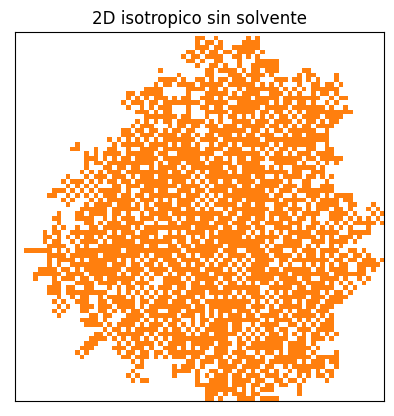

GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\2d_isotropico_sin_solvente.gif


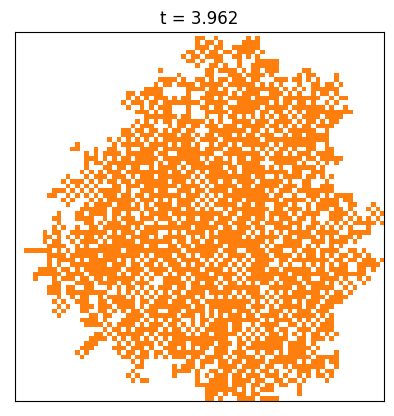

In [5]:
# Visualizacion 2D: ultimo snapshot y GIF
viz_2d_iso = KMC2DVisualizer()
if snapshots_2d_iso:
    viz_2d_iso.plot_snapshot(
        snapshots_2d_iso[-1],
        title="2D isotropico sin solvente",
        show=True,
    )
    gif_path = out_dir / "2d_isotropico_sin_solvente.gif"
    try:
        viz_2d_iso.save_gif(
            snapshots_2d_iso,
            out_path=str(gif_path),
            fps=8,
            dpi=120,
        )
        print(f"GIF guardado en: {gif_path}")
    except Exception as exc:
        print("No se pudo guardar el GIF:", exc)
else:
    print("No hay snapshots para visualizar.")

### Modelo 2D anisotropico sin solvente

In [8]:
# Modelo 2D anisotropico sin solvente
p2d_aniso = Params2D(
    Jad_x=0.10, Jad_y=0.01,
    Jinc_x=0.03, Jinc_y=0.005,
    Jdes_x=0.08, Jdes_y=0.01,
    Jmove_x=0.06, Jmove_y=0.01,
    solvent_ads_factor=1.0,
    solvent_des_factor=1.0,
    solvent_diff_factor=1.0,
    solvent_inc_factor=1.0,
 )
 # Ejecuta el motor con anisotropia marcada y sin solvente
kmc2d_aniso = KMC2D(p2d_aniso, seed=2, use_anisotropy=True, use_solvent=False)

# Corre con snapshots para visualizacion
times_2d_aniso, cover_2d_aniso, snapshots_2d_aniso = kmc2d_aniso.run_until(
    tmax=4.0, snapshot_every=1.0, store_snapshots=True
 )
grid_2d_aniso = snapshots_2d_aniso[-1][1] if snapshots_2d_aniso else kmc2d_aniso.grid.copy()
final_t = float(times_2d_aniso[-1]) if len(times_2d_aniso) else 0.0
final_cover = float(cover_2d_aniso[-1]) if len(cover_2d_aniso) else 0.0
print("2D anisotropico sin solvente:", final_t, final_cover)

0.0
0.6410883527378776
1.0482566461140315
1.3584314904380572
1.5141418083699925
1.6086407199453074
1.7140276799567353
1.830056698920698
1.9128904472856367
2.031426764640187
2.100682887645964
2.2108562717034577
2.2989023495708234
2.3909463006989977
2.5060973176220007
2.6559848434482154
2.8349143461825816
2.9434569785187343
3.0939668603027917
3.204345026164811
3.3536661167903756
3.505355989240837
3.601120960335116
3.7009016329326645
3.8210492408109054
3.9341814011311835
2D anisotropico sin solvente: 4.000386010539709 0.21171875


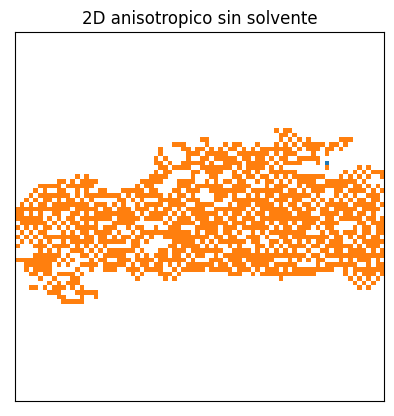

GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\2d_anisotropico_sin_solvente.gif


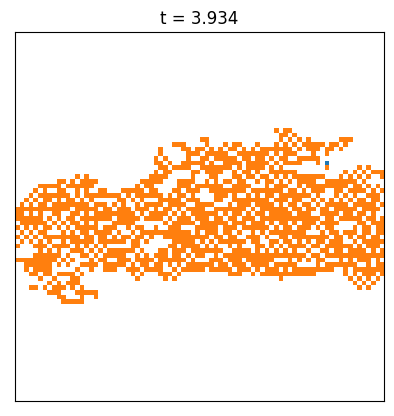

In [9]:
# Visualizacion 2D: ultimo snapshot y GIF
viz_2d_aniso = KMC2DVisualizer()
if snapshots_2d_aniso:
    viz_2d_aniso.plot_snapshot(
        snapshots_2d_aniso[-1],
        title="2D anisotropico sin solvente",
        show=True,
    )
    gif_path = out_dir / "2d_anisotropico_sin_solvente.gif"
    try:
        viz_2d_aniso.save_gif(
            snapshots_2d_aniso,
            out_path=str(gif_path),
            fps=8,
            dpi=120,
        )
        print(f"GIF guardado en: {gif_path}")
    except Exception as exc:
        print("No se pudo guardar el GIF:", exc)
else:
    print("No hay snapshots para visualizar.")

### Modelo 2D isotropico con solvente

In [14]:
# Modelo 2D isotropico con solvente
p2d_iso_sol = Params2D(
    Jad_x=0.04, Jad_y=0.04,
    Jinc_x=0.01, Jinc_y=0.01,
    Jdes_x=0.05, Jdes_y=0.05,
    Jmove_x=0.03, Jmove_y=0.03,
    solvent_ads_factor=0.6,
    solvent_des_factor=0.2,
    solvent_diff_factor=0.8,
    solvent_inc_factor=0.3,
 )
 # Ejecuta el motor sin anisotropia y con solvente
kmc2d_iso_sol = KMC2D(p2d_iso_sol, seed=3, use_anisotropy=False, use_solvent=True)

# Corre con snapshots para visualizacion
times_2d_iso_sol, cover_2d_iso_sol, snapshots_2d_iso_sol = kmc2d_iso_sol.run_until(
    tmax=4.0, snapshot_every=1.0, store_snapshots=True
 )
grid_2d_iso_sol = snapshots_2d_iso_sol[-1][1] if snapshots_2d_iso_sol else kmc2d_iso_sol.grid.copy()
final_t = float(times_2d_iso_sol[-1]) if len(times_2d_iso_sol) else 0.0
final_cover = float(cover_2d_iso_sol[-1]) if len(cover_2d_iso_sol) else 0.0
print("2D isotropico con solvente:", final_t, final_cover)

0.0
0.6319978349798516
0.9681243196782436
1.2152442766143317
1.4843906697524918
1.6127912796857757
1.8163983296283481
1.9613627148078798
2.123910823282395
2.2635209158486203
2.418008062115981
2.6169939694265345
2.756331202620209
2.865249082756318
2.9341332079341518
3.0168532369014214
3.1075141726144317
3.205193493797059
3.288594662055426
3.3790861776759815
3.450135814820172
3.52635206038209
3.6025969091086427
3.7011737835259226
3.773274452889301
3.8218363671485127
3.9036286148174777
3.962415989963938
3.997254546616927
2D isotropico con solvente: 4.00447615394552 0.2046875


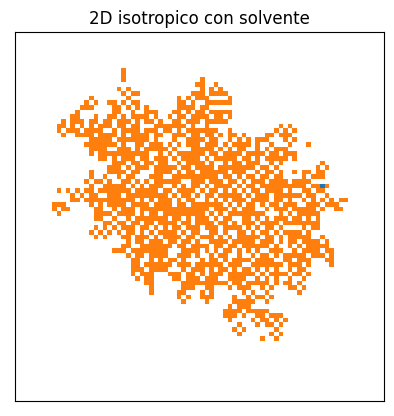

GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\2d_isotropico_con_solvente.gif


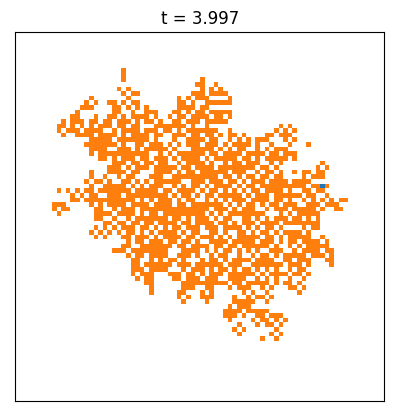

In [15]:
# Visualizacion 2D: ultimo snapshot y GIF
viz_2d_iso_sol = KMC2DVisualizer()
if snapshots_2d_iso_sol:
    viz_2d_iso_sol.plot_snapshot(
        snapshots_2d_iso_sol[-1],
        title="2D isotropico con solvente",
        show=True,
    )
    gif_path = out_dir / "2d_isotropico_con_solvente.gif"
    try:
        viz_2d_iso_sol.save_gif(
            snapshots_2d_iso_sol,
            out_path=str(gif_path),
            fps=8,
            dpi=120,
        )
        print(f"GIF guardado en: {gif_path}")
    except Exception as exc:
        print("No se pudo guardar el GIF:", exc)
else:
    print("No hay snapshots para visualizar.")

### Modelo 2D anisotropico con solvente

In [16]:
# Modelo 2D anisotropico con solvente
p2d_aniso_sol = Params2D(
    Jad_x=0.10, Jad_y=0.01,
    Jinc_x=0.03, Jinc_y=0.005,
    Jdes_x=0.08, Jdes_y=0.01,
    Jmove_x=0.06, Jmove_y=0.01,
    solvent_ads_factor=0.6,
    solvent_des_factor=0.2,
    solvent_diff_factor=0.8,
    solvent_inc_factor=0.3,
 )
 # Ejecuta el motor con anisotropia marcada y con solvente
kmc2d_aniso_sol = KMC2D(p2d_aniso_sol, seed=4, use_anisotropy=True, use_solvent=True)

# Corre con snapshots para visualizacion
times_2d_aniso_sol, cover_2d_aniso_sol, snapshots_2d_aniso_sol = kmc2d_aniso_sol.run_until(
    tmax=4.0, snapshot_every=1.0, store_snapshots=True
 )
grid_2d_aniso_sol = snapshots_2d_aniso_sol[-1][1] if snapshots_2d_aniso_sol else kmc2d_aniso_sol.grid.copy()
final_t = float(times_2d_aniso_sol[-1]) if len(times_2d_aniso_sol) else 0.0
final_cover = float(cover_2d_aniso_sol[-1]) if len(cover_2d_aniso_sol) else 0.0
print("2D anisotropico con solvente:", final_t, final_cover)

0.0
1.1108702802537684
1.449235856893856
1.9578986759577772
2.176127013503995
2.496369211747869
2.709233004513331
2.8351536582161723
2.951124861434327
3.1501581316603
3.3459491078854504
3.480535557253037
3.6345469523867635
3.7396354671485974
3.8611006551284937
3.959971075031117
2D anisotropico con solvente: 4.000809449814757 0.10390625


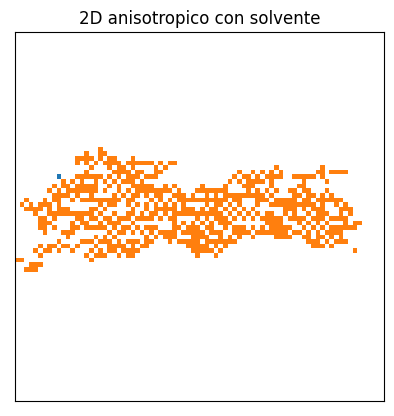

GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\2d_anisotropico_con_solvente.gif


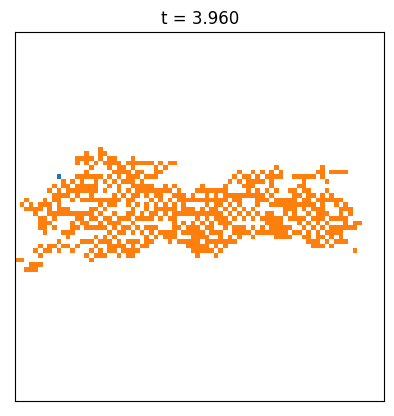

In [17]:
# Visualizacion 2D: ultimo snapshot y GIF
viz_2d_aniso_sol = KMC2DVisualizer()
if snapshots_2d_aniso_sol:
    viz_2d_aniso_sol.plot_snapshot(
        snapshots_2d_aniso_sol[-1],
        title="2D anisotropico con solvente",
        show=True,
    )
    gif_path = out_dir / "2d_anisotropico_con_solvente.gif"
    try:
        viz_2d_aniso_sol.save_gif(
            snapshots_2d_aniso_sol,
            out_path=str(gif_path),
            fps=8,
            dpi=120,
        )
        print(f"GIF guardado en: {gif_path}")
    except Exception as exc:
        print("No se pudo guardar el GIF:", exc)
else:
    print("No hay snapshots para visualizar.")

### Modelo 3D isotropico sin solvente (concentracion dinamica)

In [20]:
# Modelo 3D isotropico sin solvente con concentracion dinamica
lat3d_iso_dyn = LatticeSOS_v4((50, 50), seed=1)
lat3d_iso_dyn.initialize(mode="flat")

# Puntos de tiempo para snapshots
snapshot_times_3d_iso_dyn = np.linspace(0.0, 20.0, 20)

# Parametros isotropicos (x = y)
p3d_iso = KMCParams_v4(
    K0_plus=2.13,
    E_pb_over_kT_x=1.5,
    E_pb_over_kT_y=1.5,
    phi_over_kT=4.0,
    delta_x=0.3,
    delta_y=0.3,
    V=1.0e5,
    C_eq=1.0e-2,
    fixed_sigma=None,
    solvent_ads_factor=1.0,
    solvent_des_factor=1.0,
    solvent_mig_factor=1.0,
 )

# Ejecuta con concentracion dinamica y solvente desactivado
kmc3d_iso_dyn = KMC_BKL_v4(
    lattice=lat3d_iso_dyn,
    params=p3d_iso,
    N_bulk0=5000,
    rng_seed=1,
    time_scale=50.0,
    n_seeds=10,
    debug=False,
    constant_concentration=False,
    use_solvent=False,
 )
snaps_3d_iso_dyn, stats_3d_iso_dyn = kmc3d_iso_dyn.run(
    t_end=20.0, snapshot_times=snapshot_times_3d_iso_dyn, max_events=5000
 )
print("3D isotropico dinamico:", stats_3d_iso_dyn["total_time"], stats_3d_iso_dyn["event_counts"])

3D isotropico dinamico: 3.415455607462507 {'adsorption': 1812, 'desorption': 996, 'migration': 2192}


🧩 Usando último snapshot disponible: t=20.000 (conv=0.00%)


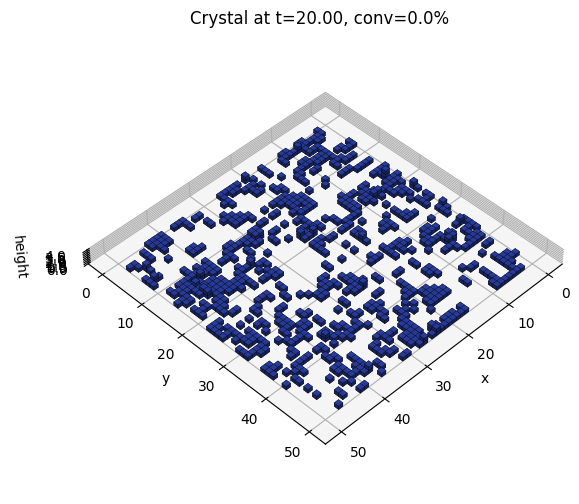

💾 GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_isotropico_dinamico.gif
GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_isotropico_dinamico.gif


In [21]:
# Visualizacion 3D: ultimo snapshot y GIF
plotter_3d_iso_dyn = Plotter(kmc3d_iso_dyn)
if snaps_3d_iso_dyn:
    plotter_3d_iso_dyn.plot_crystal_3d(
        mode="voxel",
        snapshots=snaps_3d_iso_dyn,
    )
    gif_path = out_dir / "3d_isotropico_dinamico.gif"
    try:
        plotter_3d_iso_dyn.crystal_growth_gif(
            snaps_3d_iso_dyn,
            save_path=str(gif_path),
            mode="voxel",
            fps=8,
            every_n=1,
        )
        print(f"GIF guardado en: {gif_path}")
    except Exception as exc:
        print("No se pudo guardar el GIF:", exc)
else:
    print("No hay snapshots para visualizar.")

### Modelo 3D isotropico sin solvente (concentracion estatica)

In [22]:
# Modelo 3D isotropico sin solvente con concentracion estatica
lat3d_iso_static = LatticeSOS_v4((50, 50), seed=2)
lat3d_iso_static.initialize(mode="flat")

# Puntos de tiempo para snapshots
snapshot_times_3d_iso_static = np.linspace(0.0, 20.0, 20)

# Parametros isotropicos (x = y)
p3d_iso_static = KMCParams_v4(
    K0_plus=2.13,
    E_pb_over_kT_x=1.5,
    E_pb_over_kT_y=1.5,
    phi_over_kT=4.0,
    delta_x=0.3,
    delta_y=0.3,
    V=1.0e5,
    C_eq=1.0e-2,
    fixed_sigma=2.0,
    solvent_ads_factor=1.0,
    solvent_des_factor=1.0,
    solvent_mig_factor=1.0,
 )

# Ejecuta con concentracion estatica y solvente desactivado
kmc3d_iso_static = KMC_BKL_v4(
    lattice=lat3d_iso_static,
    params=p3d_iso_static,
    N_bulk0=5000,
    rng_seed=2,
    time_scale=50.0,
    n_seeds=10,
    debug=False,
    constant_concentration=True,
    use_solvent=False,
 )
snaps_3d_iso_static, stats_3d_iso_static = kmc3d_iso_static.run(
    t_end=20.0, snapshot_times=snapshot_times_3d_iso_static, max_events=5000
 )
print("3D isotropico estatico:", stats_3d_iso_static["total_time"], stats_3d_iso_static["event_counts"])

3D isotropico estatico: 4.489140485302859 {'adsorption': 1618, 'desorption': 1083, 'migration': 2299}


🧩 Usando último snapshot disponible: t=20.000 (conv=0.00%)


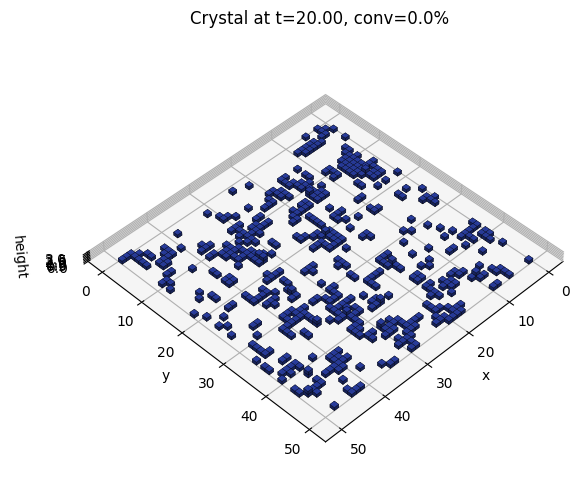

💾 GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_isotropico_estatico.gif
GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_isotropico_estatico.gif


In [23]:
# Visualizacion 3D: ultimo snapshot y GIF
plotter_3d_iso_static = Plotter(kmc3d_iso_static)
if snaps_3d_iso_static:
    plotter_3d_iso_static.plot_crystal_3d(
        mode="voxel",
        snapshots=snaps_3d_iso_static,
    )
    gif_path = out_dir / "3d_isotropico_estatico.gif"
    try:
        plotter_3d_iso_static.crystal_growth_gif(
            snaps_3d_iso_static,
            save_path=str(gif_path),
            mode="voxel",
            fps=8,
            every_n=1,
        )
        print(f"GIF guardado en: {gif_path}")
    except Exception as exc:
        print("No se pudo guardar el GIF:", exc)
else:
    print("No hay snapshots para visualizar.")

### Modelo 3D anisotropico sin solvente (concentracion estatica)

In [6]:
# Modelo 3D anisotropico sin solvente con concentracion estatica
lat3d_aniso_static = LatticeSOS_v4((50, 50), seed=3)
lat3d_aniso_static.initialize(mode="seeds", n_seeds=10)

# Puntos de tiempo para snapshots
snapshot_times_3d_aniso_static = np.linspace(0.0, 10.0, 10)

# Parametros anisotropicos con contraste marcado
p3d_aniso_static = KMCParams_v4(
    K0_plus=0.213,
    E_pb_over_kT_x= 3.0, #0.30,
    E_pb_over_kT_y= 0.2, #1.5,
    phi_over_kT= 3.2, #1.60,
    delta_x= 1.8, #0.2,
    delta_y= 0.1, #0.7,
    V=1.,
    C_eq=12.0,
    fixed_sigma=2.0,
    # solvent_ads_factor=1.0,
    # solvent_des_factor=1.0,
    # solvent_mig_factor=1.0,
 )


# Ejecuta con concentracion estatica y solvente desactivado
kmc3d_aniso_static = KMC_BKL_v4(
    lattice=lat3d_aniso_static,
    params=p3d_aniso_static,
    N_bulk0=5000,
    rng_seed=3,
    time_scale=10.0,
    n_seeds=0,
    debug=False,
    constant_concentration=True,
    use_solvent=False,
 )
snaps_3d_aniso_static, stats_3d_aniso_static = kmc3d_aniso_static.run(
    t_end=20.0, snapshot_times=snapshot_times_3d_aniso_static, max_events=5000
 )
print("3D anisotropico estatico:", stats_3d_aniso_static["total_time"], stats_3d_aniso_static["event_counts"])

3D anisotropico estatico: 9.708346076452031 {'adsorption': 3163, 'desorption': 597, 'migration': 1240}


🧩 Usando último snapshot disponible: t=10.000 (conv=0.00%)


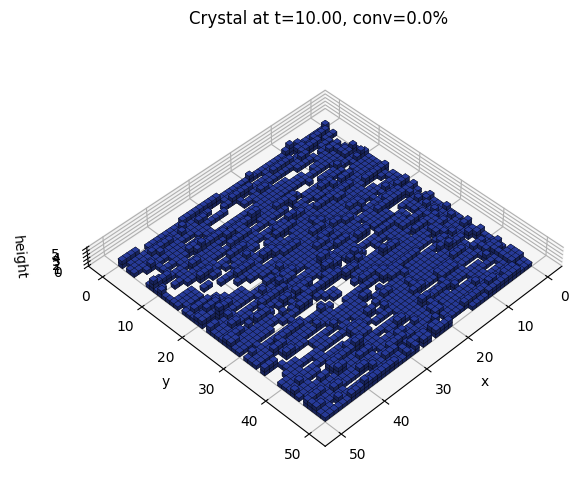

💾 GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_anisotropico_estatico.gif
GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_anisotropico_estatico.gif


In [7]:
# Visualizacion 3D: ultimo snapshot y GIF
plotter_3d_aniso_static = Plotter(kmc3d_aniso_static)
if snaps_3d_aniso_static:
    plotter_3d_aniso_static.plot_crystal_3d(
        mode="voxel",
        snapshots=snaps_3d_aniso_static,
    )
    gif_path = out_dir / "3d_anisotropico_estatico.gif"
    try:
        plotter_3d_aniso_static.crystal_growth_gif(
            snaps_3d_aniso_static,
            save_path=str(gif_path),
            mode="voxel",
            fps=8,
            every_n=1,
        )
        print(f"GIF guardado en: {gif_path}")
    except Exception as exc:
        print("No se pudo guardar el GIF:", exc)
else:
    print("No hay snapshots para visualizar.")

### Modelo 3D isotropico con solvente (concentracion estatica)

In [ ]:
# Modelo 3D isotropico con solvente con concentracion estatica
lat3d_iso_sol = LatticeSOS_v4((20, 20), seed=4)
lat3d_iso_sol.initialize(mode="flat")

# Puntos de tiempo para snapshots
snapshot_times_3d_iso_sol = np.linspace(0.0, 20.0, 20)

# Parametros isotropicos con factores de solvente
p3d_iso_sol = KMCParams_v4(
    K0_plus=1.0e3,
    E_pb_over_kT_x=1.5,
    E_pb_over_kT_y=1.5,
    phi_over_kT=4.0,
    delta_x=0.3,
    delta_y=0.3,
    V=1.0e5,
    C_eq=1.0e-2,
    fixed_sigma=None,
    solvent_ads_factor=0.7,
    solvent_des_factor=1.2,
    solvent_mig_factor=0.8,
 )

# Ejecuta con concentracion estatica y solvente activado
kmc3d_iso_sol = KMC_BKL_v4(
    lattice=lat3d_iso_sol,
    params=p3d_iso_sol,
    N_bulk0=10000,
    rng_seed=4,
    time_scale=50.0,
    n_seeds=10,
    debug=False,
    constant_concentration=True,
    use_solvent=True,
 )
snaps_3d_iso_sol, stats_3d_iso_sol = kmc3d_iso_sol.run(
    t_end=20.0, snapshot_times=snapshot_times_3d_iso_sol, max_events=5000
 )
print("3D isotropico con solvente:", stats_3d_iso_sol["total_time"], stats_3d_iso_sol["event_counts"])

In [ ]:
# Visualizacion 3D: ultimo snapshot y GIF
plotter_3d_iso_sol = Plotter(kmc3d_iso_sol)
if snaps_3d_iso_sol:
    plotter_3d_iso_sol.plot_crystal_3d(
        mode="voxel",
        snapshots=snaps_3d_iso_sol,
    )
    gif_path = out_dir / "3d_isotropico_con_solvente.gif"
    try:
        plotter_3d_iso_sol.crystal_growth_gif(
            snaps_3d_iso_sol,
            save_path=str(gif_path),
            mode="voxel",
            fps=8,
            every_n=1,
        )
        print(f"GIF guardado en: {gif_path}")
    except Exception as exc:
        print("No se pudo guardar el GIF:", exc)
else:
    print("No hay snapshots para visualizar.")

### Modelo 3D anisotropico con solvente (concentracion estatica)

In [ ]:
# Modelo 3D anisotropico con solvente con concentracion estatica
lat3d_aniso_sol = LatticeSOS_v4((20, 20), seed=5)
lat3d_aniso_sol.initialize(mode="flat")

# Puntos de tiempo para snapshots
snapshot_times_3d_aniso_sol = np.linspace(0.0, 20.0, 20)

# Parametros anisotropicos con solvente y contraste marcado
p3d_aniso_sol = KMCParams_v4(
    K0_plus=1.0e3,
    E_pb_over_kT_x=2.0,
    E_pb_over_kT_y=0.5,
    phi_over_kT=4.0,
    delta_x=0.6,
    delta_y=0.1,
    V=1.0e5,
    C_eq=1.0e-2,
    fixed_sigma=None,
    solvent_ads_factor=0.65,
    solvent_des_factor=1.3,
    solvent_mig_factor=0.75,
 )

# Ejecuta con concentracion estatica y solvente activado
kmc3d_aniso_sol = KMC_BKL_v4(
    lattice=lat3d_aniso_sol,
    params=p3d_aniso_sol,
    N_bulk0=10000,
    rng_seed=5,
    time_scale=50.0,
    n_seeds=10,
    debug=False,
    constant_concentration=True,
    use_solvent=True,
 )
snaps_3d_aniso_sol, stats_3d_aniso_sol = kmc3d_aniso_sol.run(
    t_end=20.0, snapshot_times=snapshot_times_3d_aniso_sol, max_events=5000
 )
print("3D anisotropico con solvente:", stats_3d_aniso_sol["total_time"], stats_3d_aniso_sol["event_counts"])

In [ ]:
# Visualizacion 3D: ultimo snapshot y GIF
plotter_3d_aniso_sol = Plotter(kmc3d_aniso_sol)
if snaps_3d_aniso_sol:
    plotter_3d_aniso_sol.plot_crystal_3d(
        mode="voxel",
        snapshots=snaps_3d_aniso_sol,
    )
    gif_path = out_dir / "3d_anisotropico_con_solvente.gif"
    try:
        plotter_3d_aniso_sol.crystal_growth_gif(
            snaps_3d_aniso_sol,
            save_path=str(gif_path),
            mode="voxel",
            fps=8,
            every_n=1,
        )
        print(f"GIF guardado en: {gif_path}")
    except Exception as exc:
        print("No se pudo guardar el GIF:", exc)
else:
    print("No hay snapshots para visualizar.")